In [ ]:
import batteryml
from batteryml.visualization.plot_helper import plot_capacity_degradation
from batteryml.data import BatteryData
import os
import re

folder_path = '/Mart'
b1_series = []

# Define a custom sort key that extracts the number following 'c'
def numeric_key(filename):
    # This regex looks for 'c' followed by one or more digits
    match = re.search(r'c(\d+)', filename)
    return int(match.group(1)) if match else 0

# List files that contain 'b1' and end with '.pkl'
#files = [f for f in os.listdir(folder_path) if 'b1' in f and f.endswith('.pkl')]
files = ['MATR_b1c3.pkl']
# Sort the files based on the numeric value following 'c'
sorted_files = sorted(files, key=numeric_key)

# Load the files in sorted order into the dictionary
for filename in sorted_files:
    file_path = os.path.join(folder_path, filename)
    data = BatteryData.load(file_path)
    b1_series.append(data)

print("Loaded files in sorted order:")
for f in sorted_files:
    print(f)

Loaded files in sorted order:
MATR_b1c3.pkl


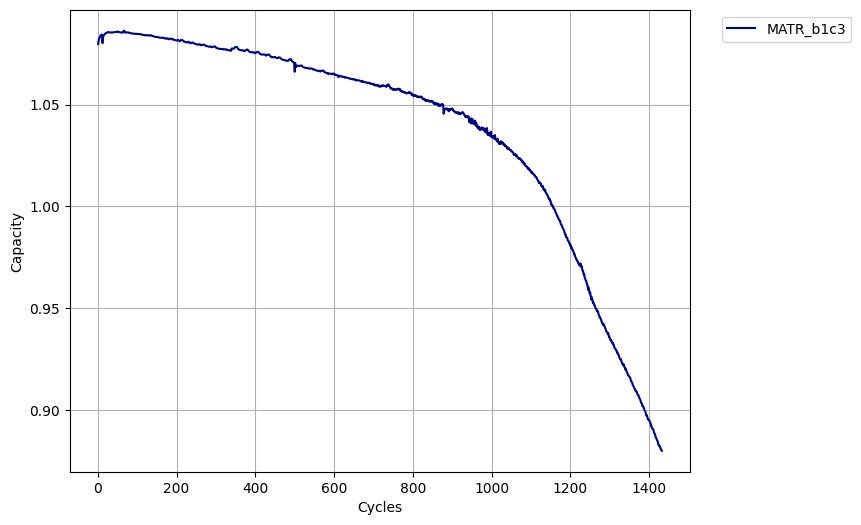

In [3]:
plot_capacity_degradation(b1_series, figsize=(8,6), normalize=False)

In [4]:
import numpy as np

def extract_capacity_series(battery_data, normalize=True):
    """
    Parameters
    ----------
    battery_data : Iterable[BatteryData]
        The same iterable you pass to `plot_capacity_degradation`.
    normalize : bool, default True
        If True, divide each cycle’s capacity by the nominal capacity so
        every curve starts near 1.0.

    Returns
    -------
    dict
        {cell_id : numpy.ndarray}  One entry per cell.
        Each value is a 1-D array of capacity values ordered by cycle number.
    """
    capacity_dict = {}

    for cell in battery_data:
        tag = cell.cell_id                      # e.g. 'MATR_b1c20'
        nominal = cell.nominal_capacity_in_Ah   # float

        # take the maximum discharge capacity in each cycle
        q_ds = [max(cycle.discharge_capacity_in_Ah)
                for cycle in cell.cycle_data]

        if normalize:
            q_ds = np.array(q_ds) / nominal
        else:
            q_ds = np.array(q_ds)

        capacity_dict[tag] = q_ds

    return capacity_dict


cap_dict = extract_capacity_series(b1_series, normalize=False)
for tag, arr in cap_dict.items():
    print(f"{tag}: {arr[:5]}  (total {len(arr)} cycles)")

MATR_b1c3: [1.0797229 1.0812283 1.0819938 1.0827308 1.083112 ]  (total 1432 cycles)


In [5]:
import numpy as np
import pwlf
slopes_list = []
breaks_list = []
for tag, arr in cap_dict.items():
    arr = arr[50:1432]  # Skip the first 50 cycles
    x = np.arange(0,len(arr))
    my_pwlf = pwlf.PiecewiseLinFit(x, arr)
    breaks = my_pwlf.fit(3)          # 5 segments = 6 breakpoints
    slopes = my_pwlf.slopes
    slopes_list.append(slopes)
    breaks_list.append(breaks)

In [6]:
import matplotlib.pyplot as plt
import numpy as np

def segmented_lines_with_breakpoints(slopes, break_points):
    if len(slopes) != len(break_points) - 1:
        raise ValueError("The number of slopes must be one less than the number of break points.")
    
    # Initialize lists to hold the x and y coordinates
    x_total = []
    y_total = []

    # Starting point for the first segment
    previous_y = 1.087
    # Loop through each slope and corresponding break point to form segments
    for i in range(len(slopes)):
        start = break_points[i]
        end = break_points[i + 1]
        
        # Define the x values for the current segment
        x = np.linspace(start, end, 100)
        # Calculate the corresponding y values based on the slope
        # Adjust y values to start from the last segment's end point
        y = previous_y + slopes[i] * (x - start)

        # Append the coordinates to the totals
        x_total.extend(x)
        y_total.extend(y)

        # Update previous_y to the last value of current y
        previous_y = y[-1]

    return x_total, y_total



# Example of using the function
slopes = slopes_list[0]   # Slopes for each segment
break_points = breaks_list[0] + 50 # Break points, shifted by 50 to match the original data's x-axis

x_fit, y_fit = segmented_lines_with_breakpoints(slopes, break_points)


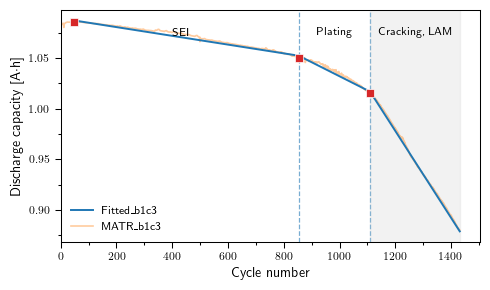

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

plt.rcParams["text.usetex"] = True

# =========================
# Global style
# =========================
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],

    "font.size": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,

    "axes.linewidth": 0.75,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.width": 0.75,
    "ytick.major.width": 0.75,
    "xtick.minor.width": 0.75,
    "ytick.minor.width": 0.75,
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,

    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# =========================
# Data
# =========================
y_matr = cap_dict["MATR_b1c3"][:1432]
x_matr = range(len(y_matr))

bp1 = 856
bp2 = 1108
indices = [49, 856, 1108]

# =========================
# Figure
# =========================
fig, ax = plt.subplots(figsize=(5, 3))

# -------------------------
# Curves
# -------------------------
ax.plot(x_fit, y_fit, color="#1F77B4", linewidth=1.4, label="Fitted\\_b1c3", zorder=3)
ax.plot(x_matr, y_matr, color="#FF7F0E", alpha=0.40, linewidth=1.2, label="MATR\\_b1c3", zorder=2)

# -------------------------
# Breakpoint lines
# -------------------------
ax.axvline(bp1, color="#1F77B4", linestyle="--", linewidth=0.9, alpha=0.6, zorder=4)
ax.axvline(bp2, color="#1F77B4", linestyle="--", linewidth=0.9, alpha=0.5, zorder=4)
crack_bg = "#E6E6E6"  # soft grey
ax.axvspan(bp2, len(y_matr), color=crack_bg, alpha=0.5, zorder=0)
# -------------------------
# Key points (square markers)
# -------------------------
ax.scatter(
    indices,
    [y_matr[i] for i in indices],
    color="#D62728",
    edgecolor="white",
    linewidth=0.5,
    s=28,
    marker="s",
    zorder=5
)

# -------------------------
# Axis labels
# -------------------------
ax.set_xlabel("Cycle number")
ax.set_ylabel(r"Discharge capacity [A$\cdot$h]")

# -------------------------
# Make x start exactly at 0
# -------------------------
ax.set_xlim(left=0)
ax.margins(x=0)

# -------------------------
# Minor ticks
# -------------------------
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))

# -------------------------
# Tick style
# -------------------------
ax.tick_params(which="both", direction="out", left=True, bottom=True, top=False, right=False)

# -------------------------
# Closed frame
# -------------------------
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.75)

# -------------------------
# Stage labels (better aligned)
# -------------------------
ymax = ax.get_ylim()[1]
ymin = ax.get_ylim()[0]

y_text = ymin + 0.90 * (ymax - ymin)

ax.text(0.5 * bp1, y_text, "SEI", ha="center", va="center", fontsize=8)
ax.text(bp1 + 0.5 * (bp2 - bp1), y_text, "Plating", ha="center", va="center", fontsize=8)
ax.text(bp2 + 0.5 * (len(y_matr) - bp2), y_text, "Cracking, LAM", ha="center", va="center", fontsize=8)

# -------------------------
# Legend (single call only)
# -------------------------
ax.legend(loc="lower left", frameon=False)

# -------------------------
# Layout
# -------------------------
plt.tight_layout()
# plt.savefig("Multistage_Segmentation.pdf", dpi=400, bbox_inches="tight")
# plt.savefig("Multistage_Segmentation.tiff", dpi=400, bbox_inches="tight")
plt.show()